# Setup Imports Plotting Configuration

In [2]:
import numpy as np 
import matplotlib.pyplot as plt
import scipy.stats as stats

plt.style.use('seaborn-v0_8-whitegrid')

plt.rcParams['figure.dpi'] = 100
np.random.seed(42)


# 1.Gaussian / Normal Distribution


Target Parameter : mu = 0.0, sigma = 1.5
Empirical mean : 0.028998083733488236
Empirical standard deviation : 1.4680893116210314
Sample Range : min = -4.861901010103609,max = 5.779097235982082


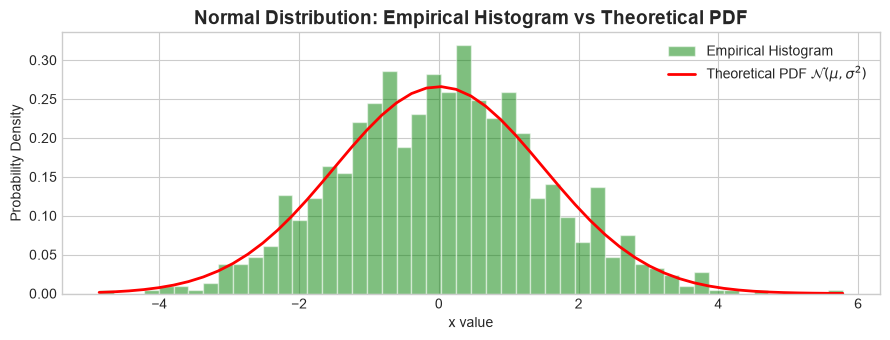

In [3]:
mu, sigma = 0.0, 1.5

#parameter for the normal distribution

#

sample_normal = np.random.normal(mu,sigma,1000)

empirical_mean = np.mean(sample_normal)
empirical_std = np.std(sample_normal)

#print value
print(f"Target Parameter : mu = {mu}, sigma = {sigma}")
print(f"Empirical mean : {empirical_mean}")
print(f"Empirical standard deviation : {empirical_std}")
print(f"Sample Range : min = {np.min(sample_normal)},max = {np.max(sample_normal)}")

## graphical representation

plt.figure(figsize=(9,3.5))
count,bins,ignored = plt.hist(sample_normal,bins=50,density=True,alpha=0.5,color='green',
edgecolor='white',label='Empirical Histogram')


pdf_normal = stats.norm.pdf(bins,loc=mu,scale=sigma)

plt.plot(bins,pdf_normal,'r-',linewidth=2, label=rf'Theoretical PDF $\mathcal{{N}}(\mu,\sigma^2)$')

plt.title("Normal Distribution: Empirical Histogram vs Theoretical PDF",fontsize=14,fontweight='bold')

plt.xlabel("x value")
plt.ylabel('Probability Density')
plt.legend(loc='upper right')
plt.tight_layout()
plt.show()

# 2.Continuous uniform Distribution (`np.random.uniform`)

Interval bounds : [-2.00,5.00]
Theoretical Mean : 1.5 | Empirical Mean : 1.525541638663858
Theoretical Variance : 4.083333333333333 | Empirical Variance : 4.070259218544439


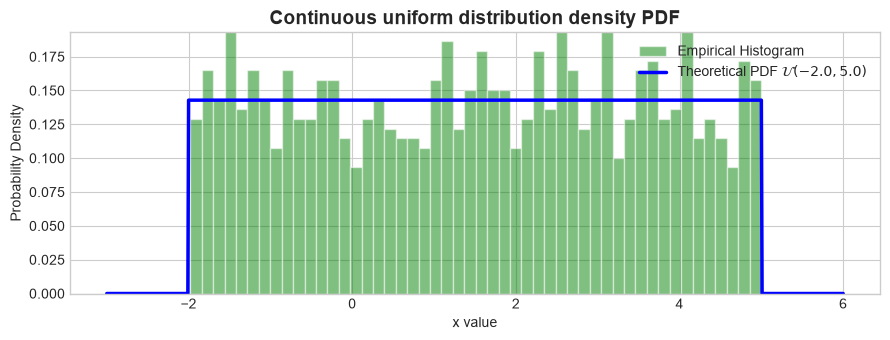

In [4]:
a,b = -2.0,5.0

sample_uniform = np.random.uniform(a,b,1000)

theoretical_mean = (a + b) / 2.0

theoretical_var = ((b-a) ** 2) / 12.0

print(f"Interval bounds : [{a:.2f},{b:.2f}]")
print(f"Theoretical Mean : {theoretical_mean} | Empirical Mean : {np.mean(sample_uniform)}")
print(f"Theoretical Variance : {theoretical_var} | Empirical Variance : {np.var(sample_uniform)}")

plt.figure(figsize=(9,3.5))

plt.hist(sample_uniform,bins=50,density=True,alpha=0.5,color='green',edgecolor='white',label='Empirical Histogram')

x_axis = np.linspace(a-1.0,b+1.0,1000)
pdf_uniform = stats.uniform.pdf(x_axis,loc=a,scale=b-a)

plt.plot(x_axis,pdf_uniform,color='blue',linewidth=2.5, label=f'Theoretical PDF $\\mathcal{{U}}({a},{b})$')

plt.title("Continuous uniform distribution density PDF",fontsize=14,fontweight='bold')

plt.xlabel("x value")
plt.ylabel('Probability Density')
plt.ylim(0,1.0/(b-a) + 0.05)
plt.legend(loc='upper right')
plt.tight_layout()
plt.show()

# 3. Exponential Distribution (np.random.exponential)

=== 3. EXPONENTIAL DISTRIBUTION OUTPUT ===
Target Scale (beta = 1/lambda) : 2.00
Empirical Mean                : 1.9734
Empirical Variance            : 3.9042 (Theoretical: 4.00)
Median Waiting Time           : 1.3523



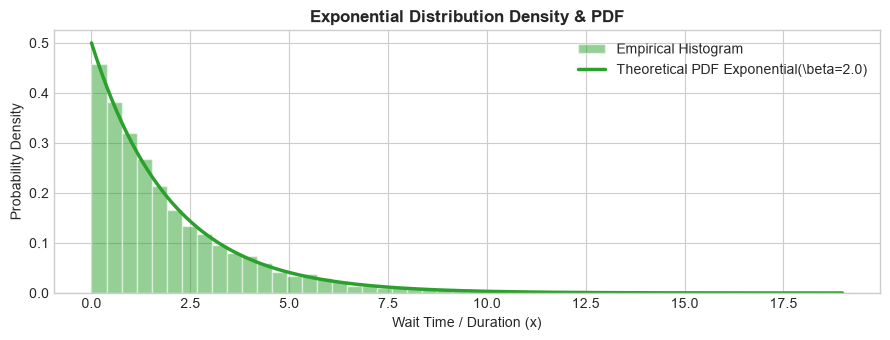

In [10]:
# --- 1. DATA GENERATION & PRINT OUTPUT ---
beta_scale = 2.0                                    # Mean duration scale beta = 2.0 (Rate lambda = 0.5)

# np.random.exponential Function Parameters Explained:
# - scale=beta_scale: Scale parameter beta = 1/lambda representing average duration between arrivals (2.0)
# - size=10000       : Number of random waiting times sampled
samples_exp = np.random.exponential(scale=beta_scale, size=10000)

print("=== 3. EXPONENTIAL DISTRIBUTION OUTPUT ===")
print(f"Target Scale (beta = 1/lambda) : {beta_scale:.2f}")
print(f"Empirical Mean                : {np.mean(samples_exp):.4f}")
print(f"Empirical Variance            : {np.var(samples_exp):.4f} (Theoretical: {beta_scale**2:.2f})")
print(f"Median Waiting Time           : {np.median(samples_exp):.4f}\n")

# --- 2. GRAPHICAL VISUALIZATION ---
plt.figure(figsize=(9, 3.5))

# Histogram parameters detailed:
# - density=True: Heights scaled to yield unit total area
# - bins=50: Discrete intervals along exponential tail
# - alpha=0.5: Translucency level
# - color='#2ca02c': Forest green
# - edgecolor='white': Sharp boundary outlines
plt.hist(samples_exp, bins=50, density=True, alpha=0.5, color='#2ca02c', edgecolor='white', label='Empirical Histogram')

x_exp = np.linspace(0, np.max(samples_exp), 300)

# stats.expon.pdf Parameters Explained:
# - x (x_exp)         : Array of positive continuous evaluation values starting at 0
# - scale=beta_scale  : Scale parameter beta = 1/lambda matching mean duration (2.0)
pdf_exp = stats.expon.pdf(x_exp, scale=beta_scale)

# Plot formatting parameters detailed:
# - color='#2ca02c': Forest green line curve
# - linewidth=2.5: Line width
plt.plot(x_exp, pdf_exp, color='#2ca02c', linewidth=2.5, label=rf'Theoretical PDF Exponential(\beta={beta_scale})')

plt.title('Exponential Distribution Density & PDF', fontsize=12, fontweight='bold')
plt.xlabel('Wait Time / Duration (x)')
plt.ylabel('Probability Density')
plt.legend(loc='upper right')
plt.tight_layout()
plt.show()

=== COFFEE SHOP DOOR BELL: TIME BETWEEN DINGS ===
Target Average Interval (Minutes) : 2.00
Observed Mean Wait Time          : 1.9550
Observed Variance               : 3.7975 (Theoretical: 4.00)
Median Wait Time Between Dings  : 1.3566



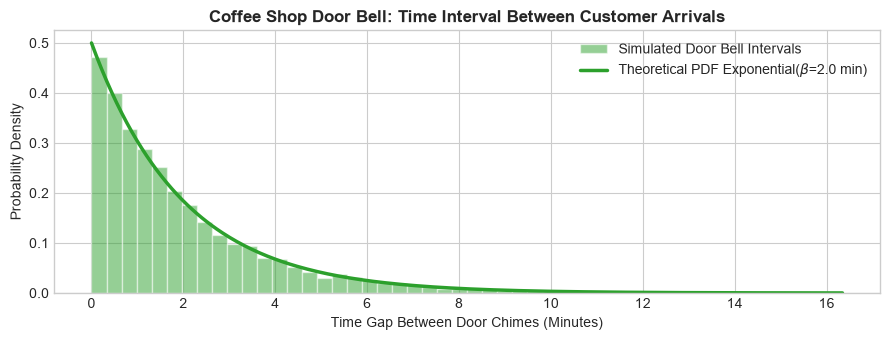

In [11]:
import numpy as np
import matplotlib.pyplot as plt
from scipy import stats

np.random.seed(42)

avg_wait_minutes = 2.0  # On average, a door bell "Ding!" happens every 2 minutes (lambda = 0.5 dings/min)
num_ding_intervals = 10000

ding_intervals = np.random.exponential(scale=avg_wait_minutes, size=num_ding_intervals)

print("=== COFFEE SHOP DOOR BELL: TIME BETWEEN DINGS ===")
print(f"Target Average Interval (Minutes) : {avg_wait_minutes:.2f}")
print(f"Observed Mean Wait Time          : {np.mean(ding_intervals):.4f}")
print(f"Observed Variance               : {np.var(ding_intervals):.4f} (Theoretical: {avg_wait_minutes**2:.2f})")
print(f"Median Wait Time Between Dings  : {np.median(ding_intervals):.4f}\n")

plt.figure(figsize=(9, 3.5))

plt.hist(ding_intervals, bins=50, density=True, alpha=0.5, color='#2ca02c', edgecolor='white', label='Simulated Door Bell Intervals')

x_intervals = np.linspace(0, np.max(ding_intervals), 300)
pdf_intervals = stats.expon.pdf(x_intervals, scale=avg_wait_minutes)

plt.plot(x_intervals, pdf_intervals, color='#2ca02c', linewidth=2.5, label=rf'Theoretical PDF Exponential($\beta$={avg_wait_minutes} min)')

plt.title('Coffee Shop Door Bell: Time Interval Between Customer Arrivals', fontsize=12, fontweight='bold')
plt.xlabel('Time Gap Between Door Chimes (Minutes)')
plt.ylabel('Probability Density')
plt.legend(loc='upper right')
plt.tight_layout()
plt.show()


# 4. Beta Distribution (np.random.beta)

=== 4. BETA DISTRIBUTION OUTPUT ===
Shape Parameters   : alpha = 2.0, beta = 5.0
Theoretical Mean   : 0.2857
Empirical Mean     : 0.2830
Sample Domain      : [0.0007, 0.8359] (Bounded in [0, 1])



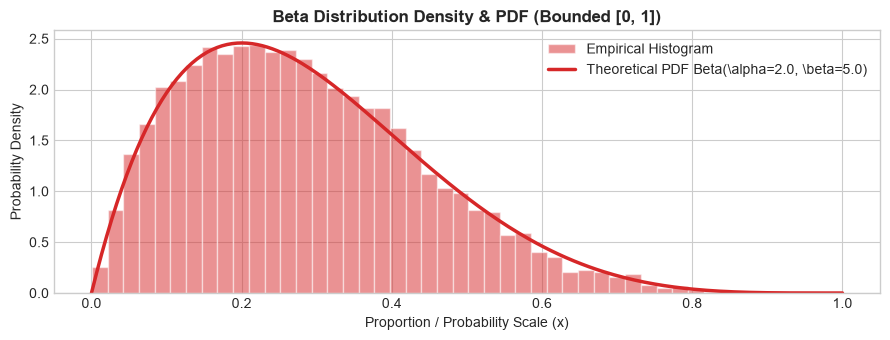

In [12]:
# --- 1. DATA GENERATION & PRINT OUTPUT ---
alpha_param, beta_param = 2.0, 5.0                  # Alpha=2 (skewed right towards 0)

# np.random.beta Function Parameters Explained:
# - a=alpha_param : Alpha shape parameter (> 0), controlling probability mass towards 1.0
# - b=beta_param  : Beta shape parameter (> 0), controlling probability mass towards 0.0
# - size=10000    : Number of random probability values sampled within bounded domain [0, 1]
samples_beta = np.random.beta(a=alpha_param, b=beta_param, size=10000)

theoretical_beta_mean = alpha_param / (alpha_param + beta_param)

print("=== 4. BETA DISTRIBUTION OUTPUT ===")
print(f"Shape Parameters   : alpha = {alpha_param:.1f}, beta = {beta_param:.1f}")
print(f"Theoretical Mean   : {theoretical_beta_mean:.4f}")
print(f"Empirical Mean     : {np.mean(samples_beta):.4f}")
print(f"Sample Domain      : [{samples_beta.min():.4f}, {samples_beta.max():.4f}] (Bounded in [0, 1])\n")

# --- 2. GRAPHICAL VISUALIZATION ---
plt.figure(figsize=(9, 3.5))

# Histogram parameters detailed:
# - density=True: Scales bin heights so cumulative area equals 1.0
# - bins=40: Discrete intervals across [0, 1] range
# - alpha=0.5: Translucency level
# - color='#d62728': Crimson red
# - edgecolor='white': Sharp boundary outlines
plt.hist(samples_beta, bins=40, density=True, alpha=0.5, color='#d62728', edgecolor='white', label='Empirical Histogram')

x_beta = np.linspace(0, 1, 300)

# stats.beta.pdf Parameters Explained:
# - x (x_beta)     : Bounded evaluation grid strictly from 0 to 1
# - a=alpha_param  : First shape parameter alpha (2.0)
# - b=beta_param   : Second shape parameter beta (5.0)
pdf_beta = stats.beta.pdf(x_beta, a=alpha_param, b=beta_param)

# Plot formatting parameters detailed:
# - color='#d62728': Crimson red line curve
# - linewidth=2.5: Line width
plt.plot(x_beta, pdf_beta, color='#d62728', linewidth=2.5, label=rf'Theoretical PDF Beta(\alpha={alpha_param}, \beta={beta_param})')

plt.title('Beta Distribution Density & PDF (Bounded [0, 1])', fontsize=12, fontweight='bold')
plt.xlabel('Proportion / Probability Scale (x)')
plt.ylabel('Probability Density')
plt.xlim(-0.05, 1.05)
plt.legend(loc='upper right')
plt.tight_layout()
plt.show()

# 5. Gamma Distribution (np.random.gamma)

=== 5. GAMMA DISTRIBUTION OUTPUT ===
Shape (k) = 3.0, Scale (theta) = 2.0
Theoretical Mean : 6.0000 | Empirical Mean : 6.0182
Theoretical Var  : 12.0000 | Empirical Var  : 12.3374



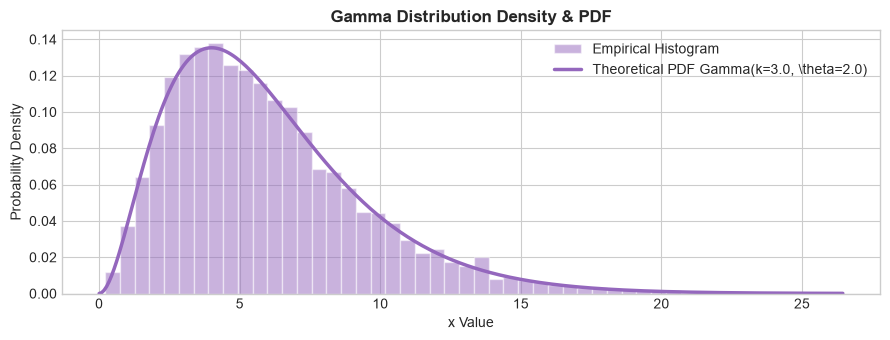

In [13]:
# --- 1. DATA GENERATION & PRINT OUTPUT ---
k_shape, theta_scale = 3.0, 2.0                      # k=3 (sum of 3 exponentials), theta=2

# np.random.gamma Function Parameters Explained:
# - shape=k_shape    : Shape parameter k (> 0) controlling profile skewness (3.0)
# - scale=theta_scale: Scale parameter theta (> 0) controlling horizontal stretching (2.0)
# - size=10000       : Number of continuous samples drawn from Gamma process
samples_gamma = np.random.gamma(shape=k_shape, scale=theta_scale, size=10000)

theoretical_gamma_mean = k_shape * theta_scale
theoretical_gamma_var = k_shape * (theta_scale**2)

print("=== 5. GAMMA DISTRIBUTION OUTPUT ===")
print(f"Shape (k) = {k_shape:.1f}, Scale (theta) = {theta_scale:.1f}")
print(f"Theoretical Mean : {theoretical_gamma_mean:.4f} | Empirical Mean : {np.mean(samples_gamma):.4f}")
print(f"Theoretical Var  : {theoretical_gamma_var:.4f} | Empirical Var  : {np.var(samples_gamma):.4f}\n")

# --- 2. GRAPHICAL VISUALIZATION ---
plt.figure(figsize=(9, 3.5))

# Histogram parameters detailed:
# - density=True: Scales bin heights to form probability density area of 1.0
# - bins=50: Discrete interval count across continuous range
# - alpha=0.5: Translucency level
# - color='#9467bd': Muted purple
# - edgecolor='white': Sharp contrast outlines
plt.hist(samples_gamma, bins=50, density=True, alpha=0.5, color='#9467bd', edgecolor='white', label='Empirical Histogram')

x_gamma = np.linspace(0, np.max(samples_gamma), 300)

# stats.gamma.pdf Parameters Explained:
# - x (x_gamma)       : Positive evaluation points across continuous domain
# - a=k_shape         : SciPy uses parameter 'a' for shape parameter k (3.0)
# - scale=theta_scale : Scale parameter theta matching scale stretching (2.0)
pdf_gamma = stats.gamma.pdf(x_gamma, a=k_shape, scale=theta_scale)

# Plot formatting parameters detailed:
# - color='#9467bd': Muted purple line curve
# - linewidth=2.5: Line width
plt.plot(x_gamma, pdf_gamma, color='#9467bd', linewidth=2.5, label=rf'Theoretical PDF Gamma(k={k_shape}, \theta={theta_scale})')

plt.title('Gamma Distribution Density & PDF', fontsize=12, fontweight='bold')
plt.xlabel('x Value')
plt.ylabel('Probability Density')
plt.legend(loc='upper right')
plt.tight_layout()
plt.show()

# Scenario 1: Total Waiting Time in a Queue (Sum of Independent Wait Times)
### Context: A coffee shop customer waits in line for multiple consecutive steps—first waiting for the barista to take their order, and then waiting for the barista to brew their coffee.

Why Gamma: If the time for a single step follows an Exponential distribution, the total combined time required to complete 
 independent steps follows a Gamma distribution (where 
 is the shape parameter).
Real-World Question: "If each of the 3 preparation steps takes an average of 2 minutes, what is the distribution of the total time a customer spends waiting for their order?"
# Scenario 2: Meteorology & Cumulative Daily Rainfall

### Context: Weather stations measure total daily or monthly precipitation in millimeters during rainy seasons.

Why Gamma: Daily rainfall amounts are strictly positive, highly skewed toward smaller quantities (many light rain days), but occasionally feature long right-hand tails representing heavy storm events.
Real-World Question: "How can meteorologists model extreme daily rainfall patterns to predict flood risks and design urban drainage systems?"

# Scenario 3: Insurance Aggregate Claims & Financial Risk Assessment
### Context: An auto insurance company calculates the total payout amount expected from policyholder claims filed over a business quarter.

Why Gamma: Individual claim payouts are always positive, with most claims being small (e.g., minor fender-benders), but a few severe accidents resulting in very high payouts. The total aggregate risk across thousands of claims follows a Gamma distribution.
Real-World Question: "How much cash reserve must an insurance provider hold to ensure a 99% probability of covering all incoming claim payouts?"

# Assignment 1

### a temperature sensor sends continuous readings between 20.0C and 25.0C
- Generate 1,000 synthetic sensor readings
- Compute the mean and median of your generated dataset
- generate a graphical visualization

Mean temperature   : 22.47 °C
Median temperature : 22.46 °C
Minimum temperature: 20.00 °C
Maximum temperature: 24.99 °C


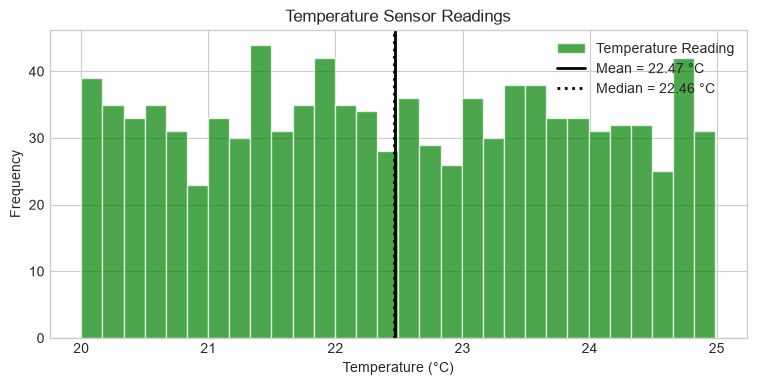

In [5]:
temperature = np.random.uniform(
    low=20,
    high=25,
    size=1000
)

temp_mean = np.mean(temperature)

temp_median = np.median(temperature)

print(f"Mean temperature   : {temp_mean:.2f} °C")
print(f"Median temperature : {temp_median:.2f} °C")
print(f"Minimum temperature: {np.min(temperature):.2f} °C")
print(f"Maximum temperature: {np.max(temperature):.2f} °C")

# graph

plt.figure(figsize=(9,4))
plt.hist(
    temperature,
    bins=30,
    color='green',
    edgecolor='white',
    label='Temperature Reading',
    alpha=0.7
)

plt.axvline(
    temp_mean,
    color='black',
    linestyle='-',
    linewidth=2,
    label=f'Mean = {temp_mean:.2f} °C'
)

plt.axvline(
    temp_median,
    color='black',
    linestyle=':',
    linewidth=2,
    label=f'Median = {temp_median:.2f} °C'
)

plt.title("Temperature Sensor Readings")
plt.xlabel("Temperature (°C)")
plt.ylabel("Frequency")
plt.legend()

plt.show()



# Assignment 2

### E-Commerce / Web Analytics (A/B Testing Simulator)

- Write a script to simulate 1000 incoming website visitors
- Assign each visitor a random float between 0.0 and 1.0 if the value is < 0.5 , route them to 'Design A', otherwise route them to 'Design B'.
- Print the percentage of visitors assigned to each design

In [6]:
visitors = 1000

random_values = np.random.random(visitors)

design_a = random_values < 0.5
design_b = random_values >= 0.5

count_a = np.sum(design_a)
count_b = np.sum(design_b)

percentage_a = (count_a / visitors) * 100
percentage_b = (count_b / visitors) * 100

print(f"Design A visitors : {count_a}")
print(f"Design B visitors : {count_b}")

print(f"Design A percentage : {percentage_a:.2f}%")
print(f"Design B percentage : {percentage_b:.2f}%")

Design A visitors : 506
Design B visitors : 494
Design A percentage : 50.60%
Design B percentage : 49.40%


# Assignment 3 

### Data Science / Computer Vision (Data Augmentation)
- Imagine building an image preprocessing pipeline for an AI model.
- Generate 500 random rotation angels for image augmentation , bounded between -15.0 and +15.0
- Plot  chart for these angles

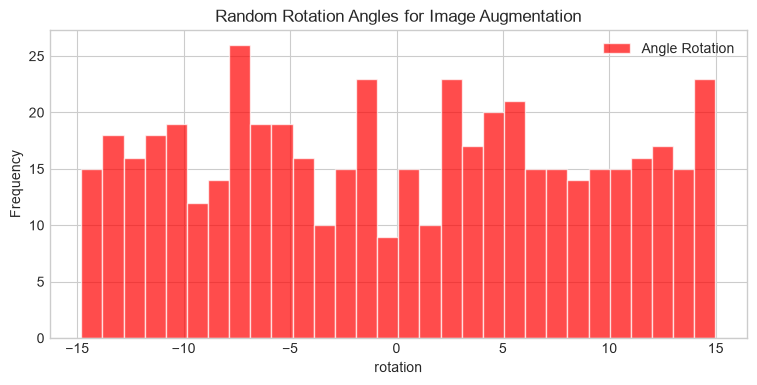

In [9]:
rotation = np.random.uniform(
    low = -15.0,
    high= 15.0,
    size=500
)
plt.figure(figsize=(9,4))

plt.hist(
    rotation,
    bins=30,
    color='red',
    edgecolor='white',
    label='Angle Rotation',
    alpha=0.7
)
plt.title('Random Rotation Angles for Image Augmentation')

plt.xlabel("rotation")
plt.ylabel("Frequency")
# plt.axvline(
#     0,
#     linestyle='--',
#     linewidth=2,
#     label='rotation'
# )

plt.legend()
plt.show()


# Assignment 4 and more are left

# 3 Exponential Distribution (np.random.exponential)